# EDA - Exploratory Data Analysis - Part 1

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import math

import warnings 
warnings.filterwarnings('ignore')

data = pd.read_excel('DataJSK.xlsx').reset_index(names = 'ID')
original_data = data.copy()
print(data.shape)
data.head()

(120000, 18)


,ID,AgeJsk,GenderID,GenderName,Haredi,HarediCities,MarritalStatusID,CasherPhone,SpouseHaredi,CityID,MilitaryServiceTypeID,Military_Service,IsHasNoEducation,ChildrenUnder18,EducationLevelID,EducationLevelName,TotalChildren,Prop_Haredim
0,0,76,1,זכר,0,0,20,0,0,7100,3,שירות צבאי,1,4,13,ללא השכלה,4,0.027
1,1,74,2,נקבה,0,0,10,0,0,3000,0,ללא שירות,1,0,1,תעודת בגרות,0,0.940
2,2,76,1,זכר,0,0,20,0,0,5000,3,שירות צבאי,1,2,11,תיכון,5,0.037
3,3,74,2,נקבה,0,0,20,0,0,3000,1,שירות לאומי,0,5,5,תואר שני,5,0.415
4,4,75,2,נקבה,0,0,40,0,0,6400,0,ללא שירות,1,0,13,ללא השכלה,4,0.020


In [55]:
# Turn Supect Haredi
suspect_haredi = data[((data.Haredi == 0) & (data.CasherPhone == 1) & (data.HarediCities == 1)) | ((data.Haredi == 0) & (data.CasherPhone == 1) & (data.SpouseHaredi == 1))]
tz_suspect_haredi = list(suspect_haredi.ID)
data['Haredi'] = data.apply(lambda row: 1 if row['ID'] in tz_suspect_haredi else row['Haredi'], axis = 1)

# Reverse data for visualization
data['EducationLevelName'] = data['EducationLevelName'].apply(lambda x: x[::-1])
data['GenderName'] = data['GenderName'].apply(lambda x: x[::-1])
data['Military_Service'] = data['Military_Service'].apply(lambda x: x[::-1])

# Create GroupeAGE Variable
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, float('inf')]
labels = ['21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '66+']
data['GroupAge'] = pd.cut(data['AgeJsk'], bins=bins, labels=labels, right=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   ID                     120000 non-null  int64   
 1   AgeJsk                 120000 non-null  int64   
 2   GenderID               120000 non-null  int64   
 3   GenderName             120000 non-null  object  
 4   Haredi                 120000 non-null  int64   
 5   HarediCities           120000 non-null  int64   
 6   MarritalStatusID       120000 non-null  int64   
 7   CasherPhone            120000 non-null  int64   
 8   SpouseHaredi           120000 non-null  int64   
 9   CityID                 120000 non-null  int64   
 10  MilitaryServiceTypeID  120000 non-null  int64   
 11  Military_Service       120000 non-null  object  
 12  IsHasNoEducation       120000 non-null  int64   
 13  ChildrenUnder18        120000 non-null  int64   
 14  EducationLevelID    

In [48]:
print(f'Shape Before:\n{original_data.Haredi.value_counts()}\n')
print(f'Shape After:\n{data.Haredi.value_counts()}\n')

Shape Before:
Haredi
0    70000
1    50000
Name: count, dtype: int64

Shape After:
Haredi
0    66783
1    53217
Name: count, dtype: int64



## EDA - Exploratory Data Analysis

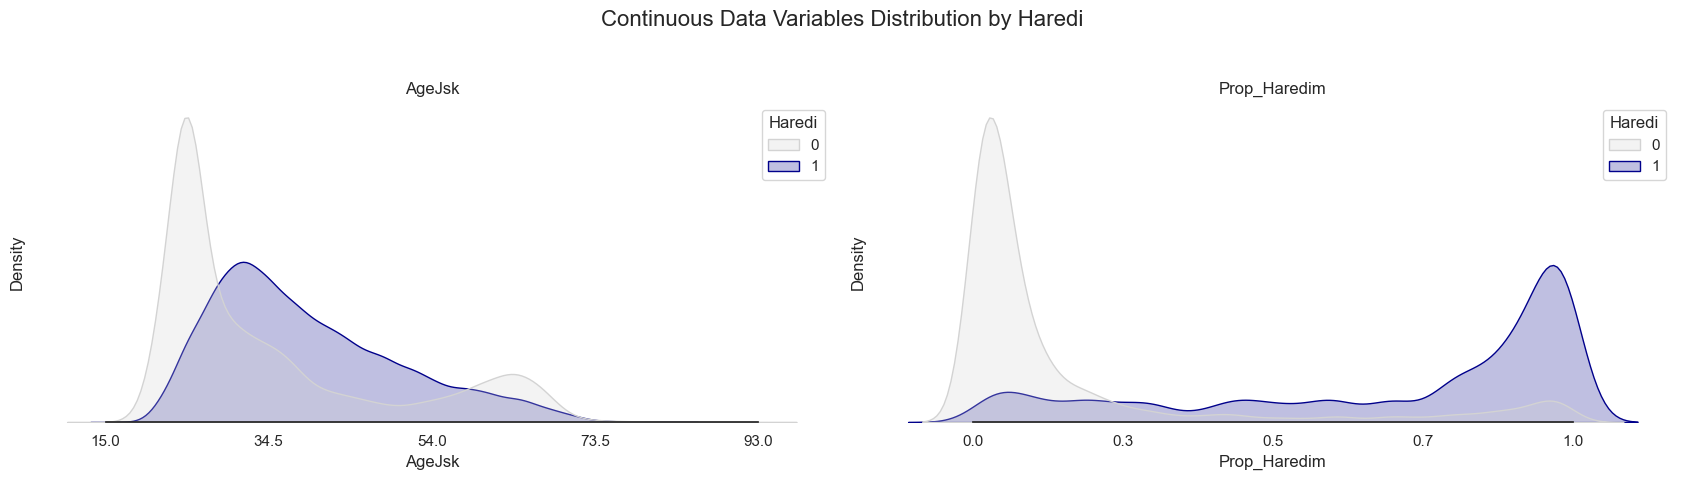

In [64]:
continuous_data = ['AgeJsk', 'Prop_Haredim']
num_plots = len(continuous_data)
n = int(math.ceil(math.sqrt(num_plots)))

sns.set_style("white")
fig = plt.figure(figsize=(17, 8))
axes = [plt.subplot(n, n, i) for i in range(1, num_plots + 1)]
plt.suptitle("Continuous Data Variables Distribution by Haredi", fontsize=16, y=1.02)

i = 0
for col in continuous_data:
    ax = axes[i]
    sns.kdeplot(data = data, x = col, hue = 'Haredi', fill = True, common_norm = False, palette={0: 'lightgray', 1: 'darkblue'}, ax = ax)
    [label.set_visible(False) for label in ax.get_yticklabels()]
    ticks = np.linspace(data[col].min(), data[col].max(), num=5)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{tick:.1f}" for tick in ticks])
    ax.set_title(col)
    i += 1

sns.despine(left=True, trim=True, fig=fig)
plt.tight_layout()
plt.show()

**Continuous Variables Distribution**

* Age (AgeJsk): Skewed left, peak at 20–30 years, then gradually decreases until ~70, very few above.

* Prop_Haredim: Bimodal — peak near 0–0.2 (low religious areas) and another near 1 (highly religious areas). Few locations in the middle range.

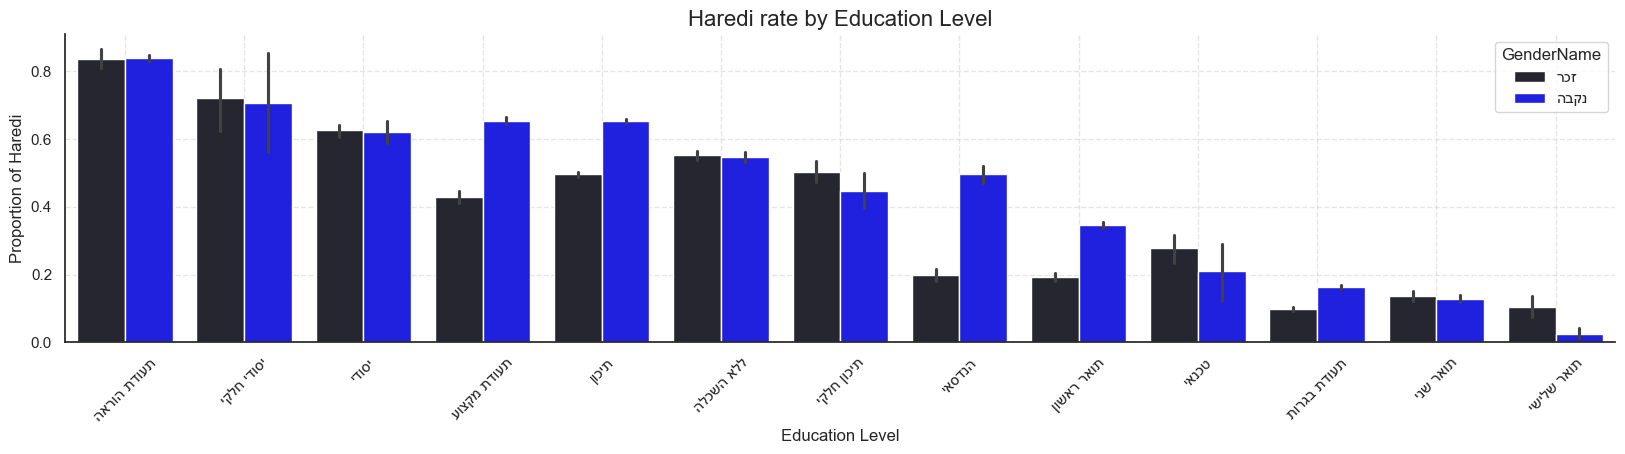

In [50]:
# Sort values
edu_order = data.groupby("EducationLevelName")["Haredi"].mean().sort_values(ascending = False).index

plt.figure(figsize = (20, 4))
sns.barplot(data = data, x = 'EducationLevelName', y = 'Haredi', order = edu_order, palette = 'dark:blue', hue = 'GenderName')
plt.xticks(rotation = 45)
plt.title("Haredi rate by Education Level", fontsize = 16)
plt.ylabel("Proportion of Haredi")
plt.xlabel("Education Level")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, alpha = 0.5, ls = '--')
plt.show()

**Conclusion – Haredi Rate by Education Level and Gender**

* Negative correlation: higher education → lower Haredi rates, for both men (זכר) and women (נקבה).

* Highest rates: low or religious education (e.g., teaching certificate, religious studies, Haredi primary schools).

* Lowest rates: higher education (Bachelor’s, Master’s, PhD, technical/engineering).

* Women generally have slightly lower Haredi rates than men at most education levels.

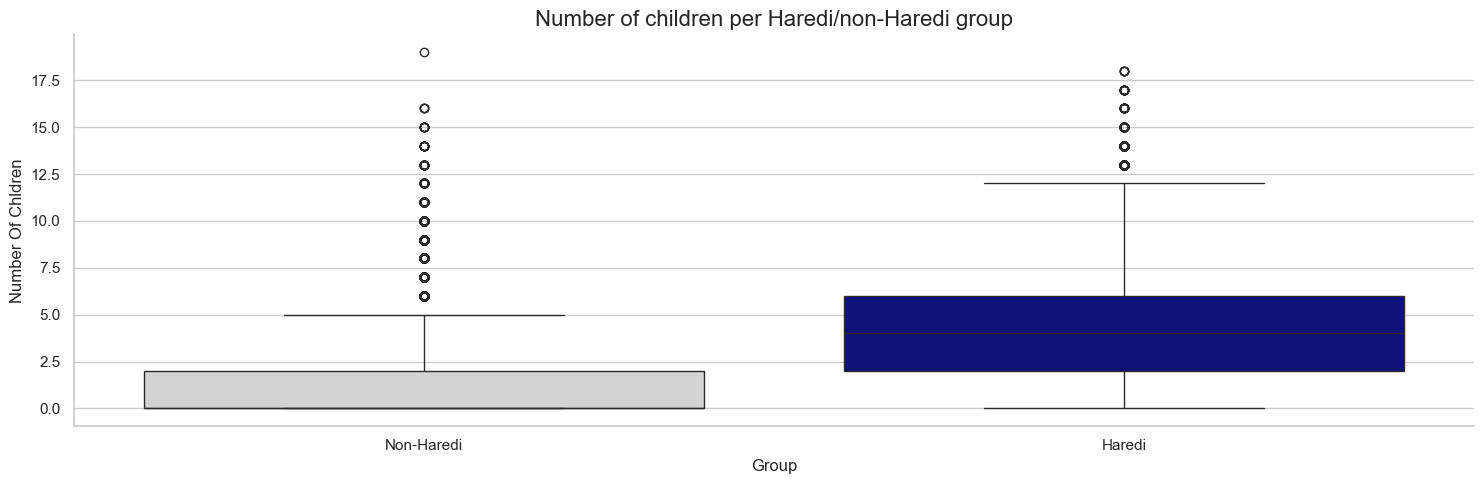

In [68]:
sns.set(style="whitegrid")
data['Haredi_str'] = data['Haredi'].astype(str)

palette = {'0': 'lightgray', '1': 'darkblue'}
plt.figure(figsize=(15, 5))
sns.boxplot(x = 'Haredi_str', y = 'TotalChildren', data = data, palette = palette)

plt.title("Number of children per Haredi/non-Haredi group", fontsize = 16)
plt.xlabel("Group", fontsize = 12)
plt.ylabel("Number Of Chldren", fontsize = 12)
plt.xticks([0, 1], ['Non-Haredi', 'Haredi'])
sns.despine()
plt.tight_layout()
plt.show()

**Conclusion – Number of Children by Haredi / Non-Haredi Group**

The boxplot shows a clear difference between the two groups in family size.

* Haredi group:

   *  Median of about 4 children, with wide variability.

    * Some families have 12 or more children (classified as outliers).

    * This reflects the large-family norms in Haredi communities.

* Non-Haredi group:

    * Median of about 1 child, with most values between 0 and 2.

    * However, there are many outliers:

        * Some have more than 5 children, even over 10.

        * These may represent rare large families or specific cultural subgroups.

Note on outliers: Even though the median is low for non-Haredim, the presence of many outliers shows that large families exist in this group, though they are atypical.

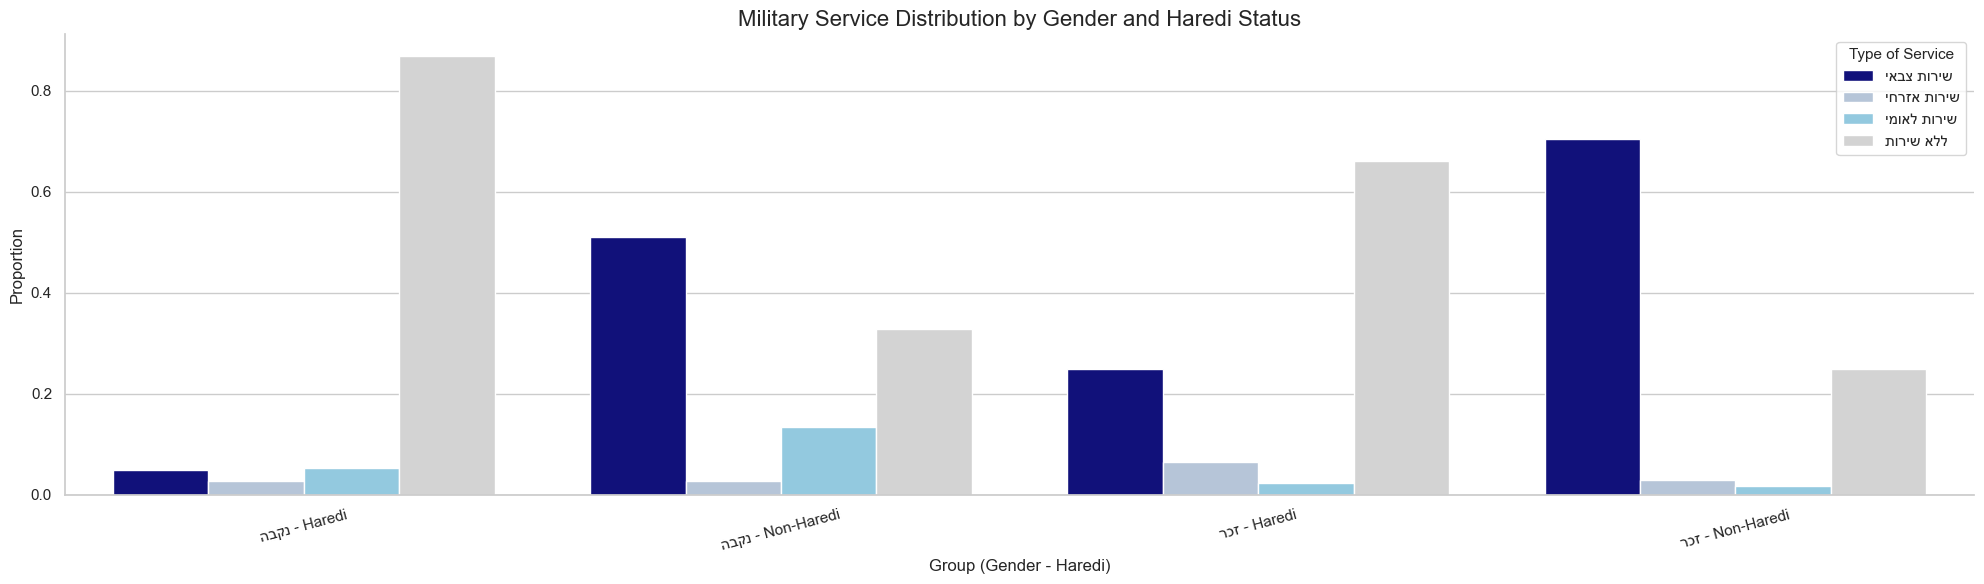

In [52]:
sns.set_style("whitegrid")

# Combined Group
data['Group'] = data['GenderName'] + " - " + data['Haredi'].map({0: "Non-Haredi", 1: "Haredi"})
counts = data.groupby(['Group', 'Military_Service']).size().reset_index(name='Count')
counts['Proportion'] = counts['Count'] / counts.groupby('Group')['Count'].transform('sum')
service_palette = { 'יאבצ תוריש': 'darkblue', 'ימואל תוריש': 'skyblue', 'תוריש אלל': 'lightgray', 'יחרזא תוריש': 'lightsteelblue' }

plt.figure(figsize=(20, 6))
sns.barplot(data = counts, x = 'Group',y = 'Proportion',hue = 'Military_Service',palette = service_palette)
plt.title("Military Service Distribution by Gender and Haredi Status", fontsize = 16)
plt.ylabel("Proportion", fontsize = 12)
plt.xlabel("Group (Gender - Haredi)", fontsize = 12)
plt.xticks(rotation = 15)
plt.legend(title="Type of Service", title_fontsize = 11)
sns.despine()
plt.tight_layout()
plt.show()

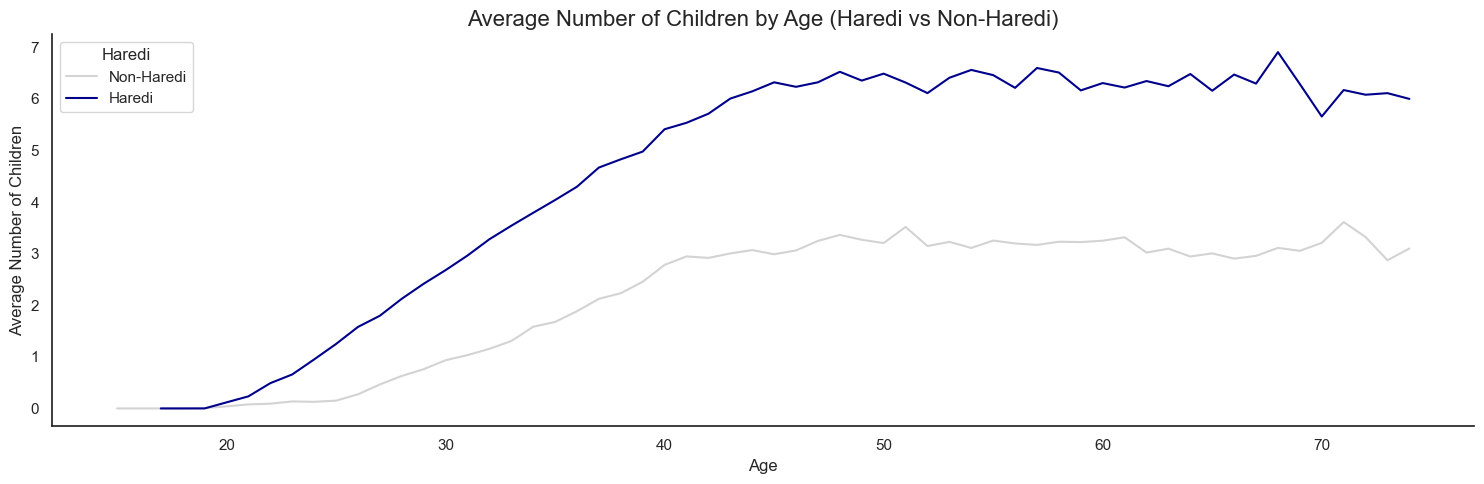

In [66]:
plt.figure(figsize = (15, 5))
sns.lineplot(data = data[data.AgeJsk < 75], x = 'AgeJsk', y = 'TotalChildren', hue = 'Haredi', estimator = 'mean', ci = None, palette = {0: 'lightgray', 1: 'darkblue'})
plt.title("Average Number of Children by Age (Haredi vs Non-Haredi)", fontsize = 16)
plt.xlabel("Age", fontsize = 12)
plt.ylabel("Average Number of Children", fontsize = 12)
plt.legend(title="Haredi", labels=["Non-Haredi", "Haredi"]) 
sns.despine()
plt.tight_layout()
plt.show()

In [53]:
data.groupby(['Haredi', 'CasherPhone'])['CasherPhone'].count()

Haredi  CasherPhone
0       0              62700
        1               4083
1       0              21002
        1              32215
Name: CasherPhone, dtype: int64

In [54]:
data.groupby(['Haredi', 'HarediCities'])['HarediCities'].count()

Haredi  HarediCities
0       0               64851
        1                1932
1       0               30775
        1               22442
Name: HarediCities, dtype: int64